<a href="https://colab.research.google.com/github/krishnakeshab-banik/credit_risk_modeling/blob/main/Credit_Risk_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option("display.max_columns", None)

In [ ]:
sns.set_style("whitegrid")

In [ ]:
df=pd.read_csv("/content/german_credit_data.csv")

In [ ]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [ ]:
df["Risk"].value_counts()

,count
Risk,
good,700
bad,300


In [ ]:
df.shape

(1000, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
df["Job"].unique()

array([2, 1, 3, 0])

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dropna().reset_index(drop=True)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [ ]:
df.drop(columns= 'Unnamed: 0', inplace= True)
#By using inplace=True, you instruct Pandas to: Update the existing object: The changes are applied to the variable itself in memory.

In [ ]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


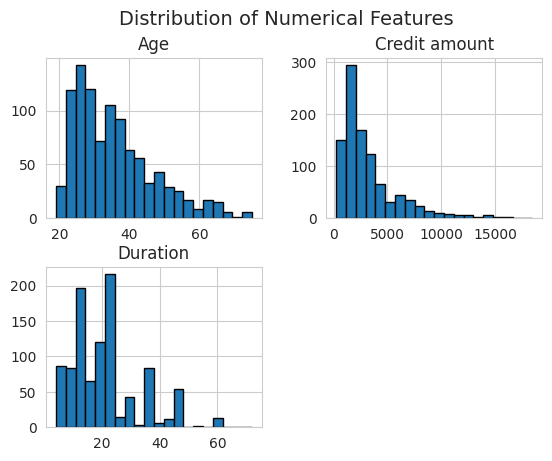

In [ ]:
df[["Age","Credit amount","Duration"]].hist(bins=20, edgecolor="black")
#bins means how many groups the data is segregated in
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

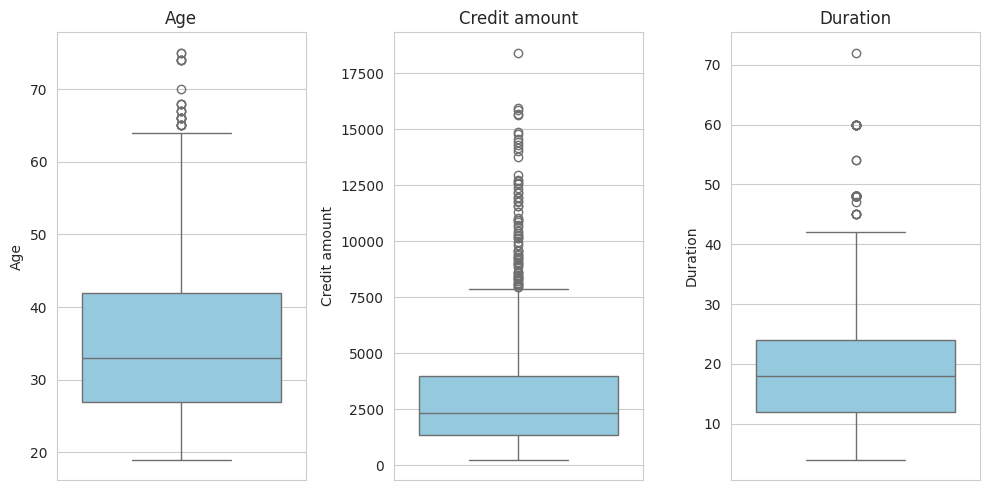

In [ ]:
plt.figure(figsize= ( 10,5))
for i, col in enumerate (["Age","Credit amount","Duration"]):
  plt.subplot(1,3,i+1)
  sns.boxplot(y=df[col], color="skyblue")
  plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
134,21,female,2,own,moderate,NaN,10144,60,radio/TV,good
255,27,male,1,own,NaN,moderate,7418,60,radio/TV,good
332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,63,male,3,free,NaN,NaN,13756,60,car,good
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,27,male,3,free,NaN,moderate,9157,60,radio/TV,good
637,21,male,2,own,little,NaN,15653,60,radio/TV,good
672,42,male,3,own,little,NaN,10366,60,car,good
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [ ]:
categorical_cols=["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]

/tmp/ipykernel_1467/3519155954.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order= df[col].value_counts().index)
/tmp/ipykernel_1467/3519155954.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order= df[col].value_counts().index)
/tmp/ipykernel_1467/3519155954.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order= df[col].value_counts().index)
/tmp/ipykernel_1467/3519155954.py:4: FutureWarning: 

Passing `palette` without assig

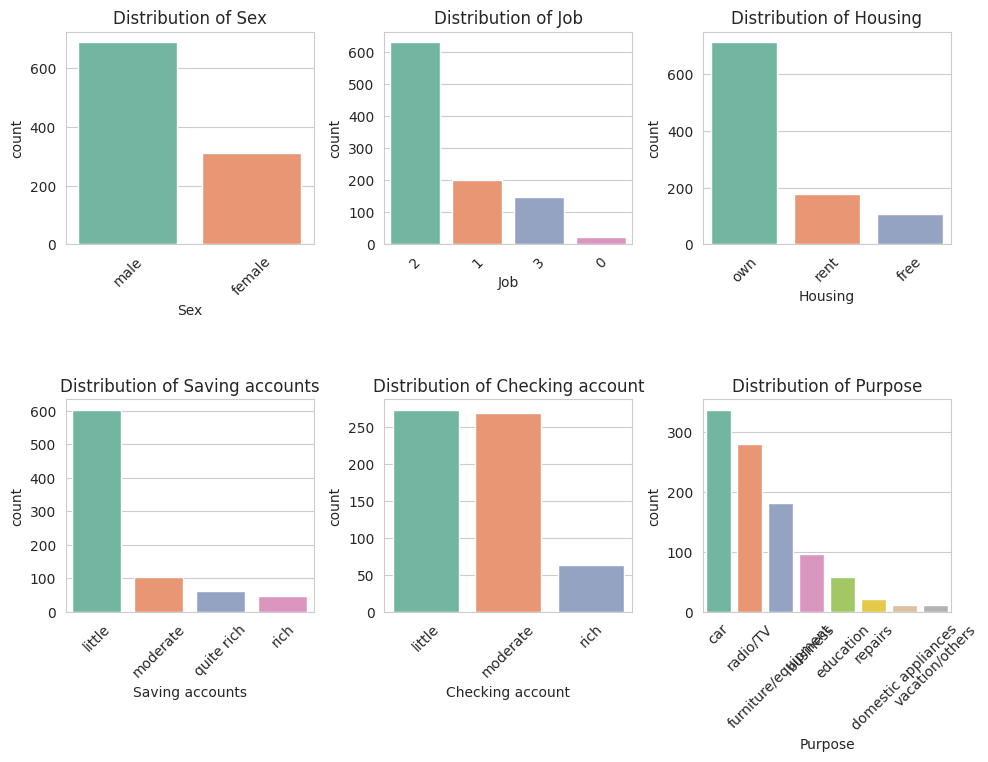

In [ ]:
plt.figure(figsize= (10,10))
for i, col in enumerate(categorical_cols):
  plt.subplot(3,3,i+1)
  sns.countplot(data=df, x=col, palette="Set2", order= df[col].value_counts().index)
  plt.title(f"Distribution of {col}")
  plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
corr= df[["Age","Job","Credit amount","Duration"]].corr()

In [ ]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.032716,-0.036136
Job,0.015673,1.000000,0.285385,0.210910
Credit amount,0.032716,0.285385,1.000000,0.624984
Duration,-0.036136,0.210910,0.624984,1.000000


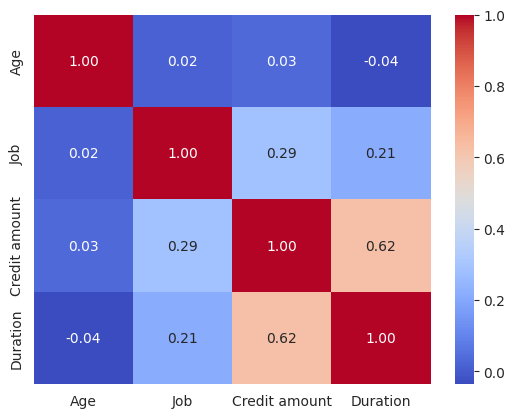

In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [ ]:
df.groupby("Job")["Credit amount"].mean()

,Credit amount
Job,
0,2745.136364
1,2358.520000
2,3070.965079
3,5435.493243


In [ ]:
df.groupby("Sex")["Credit amount"].mean()

,Credit amount
Sex,
female,2877.774194
male,3448.040580


In [ ]:
pd.pivot_table(df,values="Credit amount", index= "Housing", columns= "Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


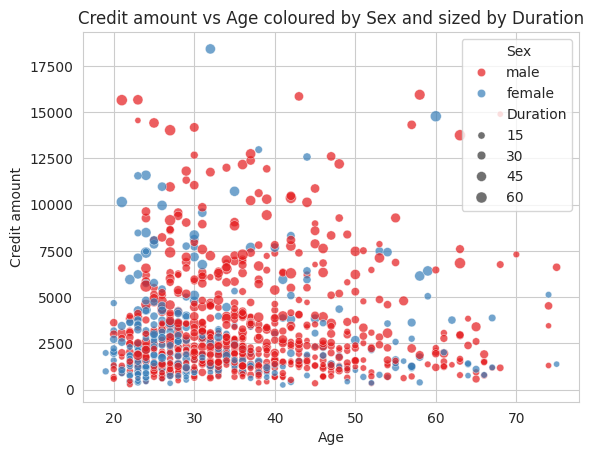

In [ ]:
sns.scatterplot(data=df,x="Age", y="Credit amount", hue="Sex", size="Duration", alpha= 0.7, palette= "Set1")
plt.title("Credit amount vs Age coloured by Sex and sized by Duration")
plt.show()

/tmp/ipykernel_1467/6506181.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data= df, x= "Saving accounts", y= "Credit amount", palette= "Pastel1")


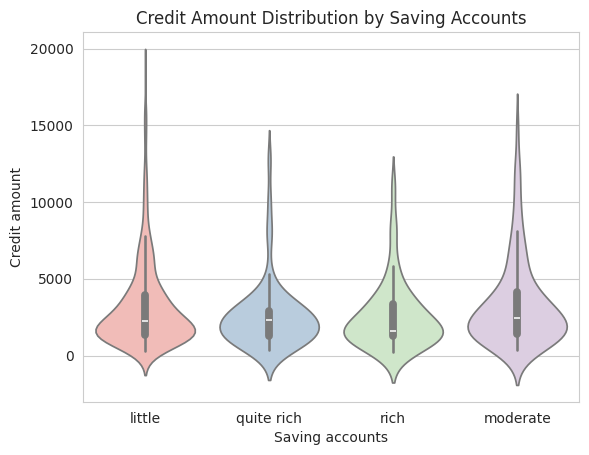

In [ ]:
sns.violinplot(data= df, x= "Saving accounts", y= "Credit amount", palette= "Pastel1")
plt.title("Credit Amount Distribution by Saving Accounts")
plt.show()

In [ ]:
df["Risk"].value_counts(normalize=True)*100

,proportion
Risk,
good,70.0
bad,30.0


/tmp/ipykernel_1467/1313710567.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Risk", y= col, palette= "Pastel2")
/tmp/ipykernel_1467/1313710567.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Risk", y= col, palette= "Pastel2")
/tmp/ipykernel_1467/1313710567.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Risk", y= col, palette= "Pastel2")


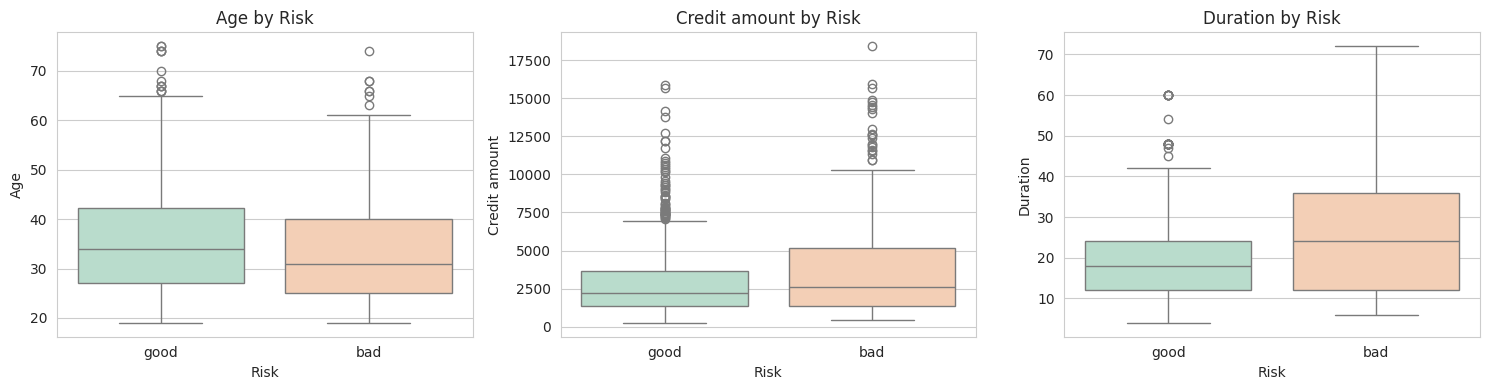

In [ ]:
plt.figure(figsize=(15,4))
for i, col in enumerate(["Age","Credit amount","Duration"]):
  plt.subplot(1,3, i+1)
  sns.boxplot(data=df,x="Risk", y= col, palette= "Pastel2")
  plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [ ]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


In [ ]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

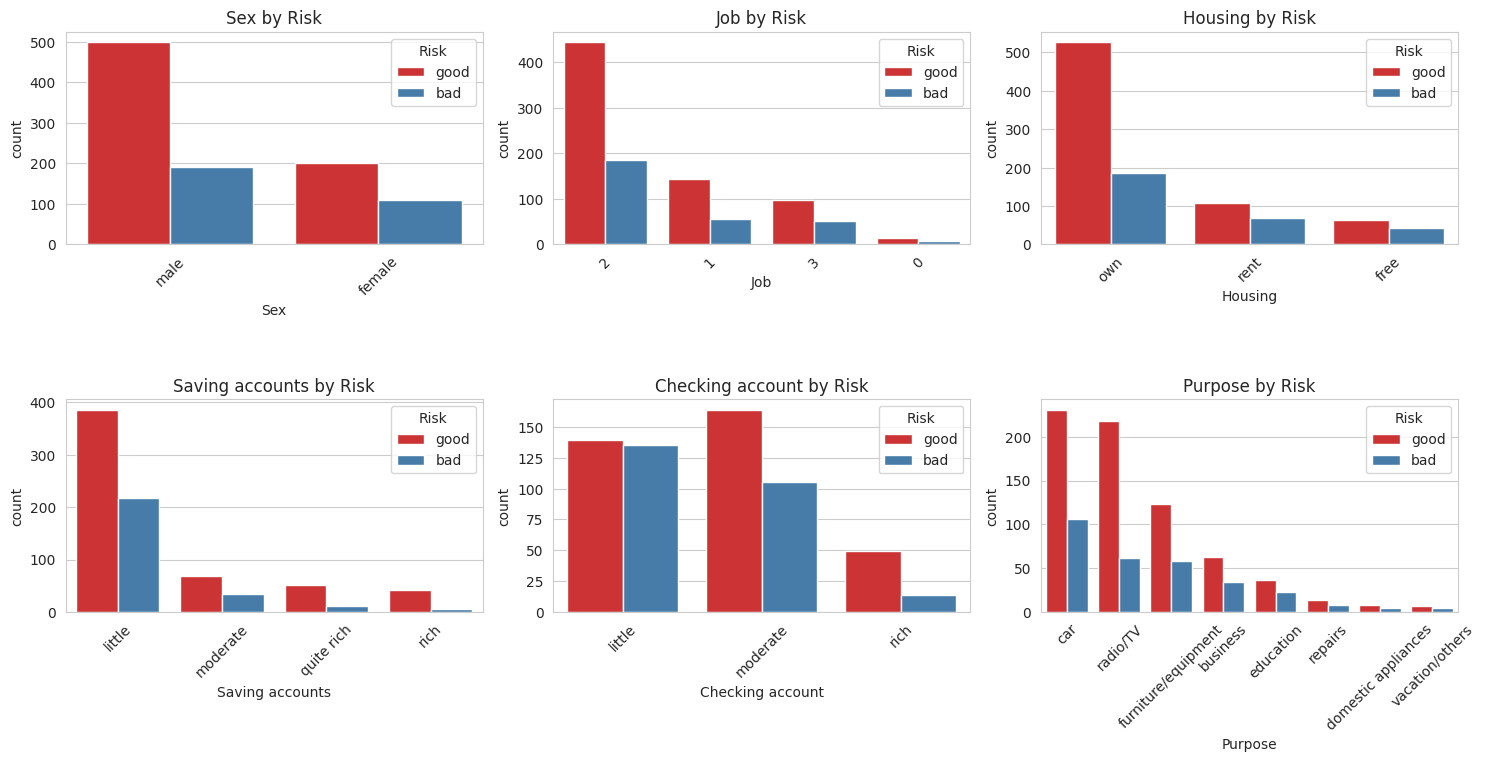

In [ ]:
plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
  plt.subplot(3,3, i+1)
  sns.countplot(data=df, x= col, hue="Risk", palette= "Set1", order = df[col].value_counts().index)
  plt.title(f"{col} by Risk")
  plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [ ]:
features= ["Age", "Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration"]

In [ ]:
target= "Risk"

In [ ]:
df_model=df[features + [target]].copy()

In [ ]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,male,2,own,NaN,little,1169,6,good
1,22,female,2,own,little,moderate,5951,48,bad
2,49,male,1,own,little,NaN,2096,12,good
3,45,male,2,free,little,little,7882,42,good
4,53,male,2,free,little,little,4870,24,bad


In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
cat_cols= df_model.select_dtypes(include="object").columns.drop("Risk")

In [ ]:
le_dict={}

In [ ]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [ ]:
for col in cat_cols:
  le= LabelEncoder()
  df_model[col]= le.fit_transform(df_model[col])
  le_dict[col]= le
  joblib.dump(le, f"{col}_encoder.pkl")

In [ ]:
le_target= LabelEncoder()

In [ ]:
target

'Risk'

In [ ]:
df_model[target]

,Risk
0,good
1,bad
2,good
3,good
4,bad
...,...
995,good
996,good
997,good
998,bad


In [ ]:
df_model[target].value_counts()

,count
Risk,
good,700
bad,300


In [ ]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [ ]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,1,2,1,4,0,1169,6,good
1,22,0,2,1,0,1,5951,48,bad
2,49,1,1,1,0,3,2096,12,good
3,45,1,2,0,0,0,7882,42,good
4,53,1,2,0,0,0,4870,24,bad


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=df_model.drop(target, axis=1)

In [ ]:
y=df_model[target]

In [ ]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,67,1,2,1,4,0,1169,6
1,22,0,2,1,0,1,5951,48
2,49,1,1,1,0,3,2096,12
3,45,1,2,0,0,0,7882,42
4,53,1,2,0,0,0,4870,24
...,...,...,...,...,...,...,...,...
995,31,0,1,1,0,3,1736,12
996,40,1,3,1,0,0,3857,30
997,38,1,2,1,0,3,804,12
998,23,1,2,0,0,0,1845,45


In [ ]:
y

,Risk
0,good
1,bad
2,good
3,good
4,bad
...,...
995,good
996,good
997,good
998,bad


In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

In [ ]:
X_train.shape

(800, 8)

In [ ]:
X_test.shape

(200, 8)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [ ]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
  grid= GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
  grid.fit(X_train, y_train)
  best_model= grid.best_estimator_
  y_pred= best_model.predict(X_test)
  acc= accuracy_score(y_test, y_pred)
  return best_model, acc, grid.best_params_

In [ ]:
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")
dt_param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
best_dt, dt_acc, best_dt_params = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)